In [21]:
import os
import torch
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import time
import math
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.neural_network import MLPClassifier
from PIL import Image

In [22]:
def find_bad_images(parent_dir):
    bad_image_list = []
    for folder in os.listdir(parent_dir):
        for filename in os.listdir(f'{parent_dir}/{folder}'):
            if filename.endswith('.jpg'):
                try:
                    img = Image.open(f'training_data/PetImages/{folder}/{filename}')
                    img.verify()
                except:
                    bad_image_list.append(f'{folder}/{filename}')
    return bad_image_list

In [3]:
%%time

parent_dir = 'training_data/PetImages'
bad_image_list = find_bad_images(parent_dir)
print(bad_image_list)

for file in bad_image_list:
    if file.endswith('.jpg'):
        print(f'Removing bad image: {file}')
        os.remove(f'{parent_dir}/{file}')

bad_image_list = find_bad_images(parent_dir)
print(bad_image_list)

C:\Users\wesle\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\TiffImagePlugin.py:866: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[]
[]
CPU times: total: 4.03 s
Wall time: 4min 6s


In [23]:
transform=transforms.Compose([
        transforms.Resize(255),
        transforms.CenterCrop(200),
        #transforms.Grayscale(),
        transforms.ToTensor()
        ])
dataset = datasets.ImageFolder('training_data/PetImages', transform=transform)

In [46]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1000, shuffle=True)
images,labels = next(iter(dataloader))

print(images.shape)

np_image_set = np.array([np.swapaxes(image.T, 0, 1) for image in images])
label_set = labels.to('cpu').detach().numpy().flatten()

print(np_image_set.shape)

torch.Size([1000, 3, 200, 200])
(1000, 200, 200, 3)


In [ ]:
#figure = plt.figure(figsize=(12,6))
#design=np.array([t[0].to('cpu').detach().numpy().flatten() for t in dataset1])

'''
print(label_set)
for i,pic in enumerate(np_image_set):
    ax = plt.subplot(2, math.ceil(len(np_image_set)/2), i+1)
    ax.set_title(f'Label: {label_set[i]}')
    ax.imshow(pic)

plt.tight_layout()
plt.show()
'''

In [47]:
X = np_image_set.reshape(np_image_set.shape[0], np_image_set.shape[1]*np_image_set.shape[2]*np_image_set.shape[3])
print(X.shape)

(1000, 120000)


In [39]:
%%time
mlp_clf = MLPClassifier(hidden_layer_sizes=(200,2), activation = 'relu', solver='lbfgs', max_iter=500).fit(X, label_set)

CPU times: total: 20min 48s
Wall time: 7min 39s


In [48]:
%%time
gpc_clf = GaussianProcessClassifier(kernel = 1.0 * RBF([1.0])).fit(X, label_set)

CPU times: total: 48.2 s
Wall time: 1min 20s


(200, 200, 3)


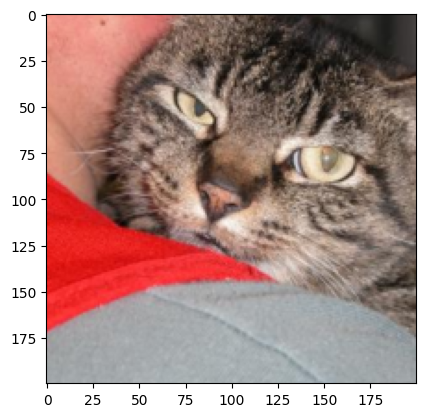

In [49]:
test_img = np_image_set[0]
print(test_img.shape)
plt.imshow(test_img)
plt.show()

In [50]:
xtest = X
#xtest = x_test.reshape(1,x_test.shape[0])
print(xtest.shape)
#y_mlp = mlp_clf.predict(xtest)
y_gpc = gpc_clf.predict(xtest)

(1000, 120000)


In [51]:
#print(y_mlp)
print(y_gpc)

[0 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 1 1 0 0 0 1 0 0
 1 0 1 1 1 1 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1 0 0 0
 1 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 1 1 1 0 1
 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0
 1 0 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1
 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 1 1 1 0 0 1 1 0 1
 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1
 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1
 0 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 1 0
 0 1 1 0 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 1 1 1 0 1 0 0 1
 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 1 0 1 

In [52]:
print(label_set)

[0 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 1 1 0 0 0 1 0 0
 1 0 1 1 1 1 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1 0 0 0
 1 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 1 1 1 0 1
 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0
 1 0 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1
 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 1 1 1 0 0 1 1 0 1
 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1
 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1
 0 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 1 0
 0 1 1 0 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 1 1 1 0 1 0 0 1
 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 1 0 1 

In [53]:
#print(len(np.where(y_mlp!=label_set)[0])/len(label_set))
print(len(np.where(y_gpc!=label_set)[0])/len(label_set))

0.0


In [54]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=100, shuffle=True)
images,labels = next(iter(dataloader))

print(images.shape)

np_image_set = np.array([np.swapaxes(image.T, 0, 1) for image in images])
label_set = labels.to('cpu').detach().numpy().flatten()
X_test = np_image_set.reshape(np_image_set.shape[0], np_image_set.shape[1]*np_image_set.shape[2]*np_image_set.shape[3])

torch.Size([100, 3, 200, 200])


In [55]:
print(X_test.shape)

(100, 120000)


In [56]:
#y_mlp = mlp_clf.predict(X_test)
y_gpc = gpc_clf.predict(X_test)
#print(len(np.where(y_mlp!=label_set)[0])/len(label_set))
print(len(np.where(y_gpc!=label_set)[0])/len(label_set))

0.48
